In [10]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint

# 🔥 1. 데이터 (작고 noisy하게)
np.random.seed(42)

X = np.linspace(0, 1, 50) # 0부터 1까지를 50개로 균등하게 나눔 #[0.0, 0.0204, 0.0408, ..., 1.0]
y = 3 * X + np.random.normal(0, 0.1, 50)  # noise 추가 = y = 직선 + 약간의 흔들림

X = X.reshape(-1, 1)
print(X.shape)
print(X)

# 🔥 2. 모델 (과하게 크게 만들어서 overfitting 유도)
model = Sequential([
    Dense(128, activation='relu', input_shape=(1,)),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

# val_loss를 계속 관찰한다.
# val_loss가 개선되지 않으면
# 5 Epoch 동안 기다린다.
# 개선되지 않으면 학습을 중단
# EarlyStopping 쓰는 이유는 = 과적합 해결

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# 체크 포인트 => 최고 성능 모델을 저장하는 역할.
checkpoint = ModelCheckpoint(
    "best_model.keras",        # 저장 파일
    monitor='val_loss',        # 기준
    save_best_only=True,       # 최고 성능만 저장
    mode='min',                # loss는 최소값 기준
    verbose=1
)

# 학습
history = model.fit(
    X, y,
    epochs=500,
    validation_split=0.3,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

(50, 1)
[[0.        ]
 [0.02040816]
 [0.04081633]
 [0.06122449]
 [0.08163265]
 [0.10204082]
 [0.12244898]
 [0.14285714]
 [0.16326531]
 [0.18367347]
 [0.20408163]
 [0.2244898 ]
 [0.24489796]
 [0.26530612]
 [0.28571429]
 [0.30612245]
 [0.32653061]
 [0.34693878]
 [0.36734694]
 [0.3877551 ]
 [0.40816327]
 [0.42857143]
 [0.44897959]
 [0.46938776]
 [0.48979592]
 [0.51020408]
 [0.53061224]
 [0.55102041]
 [0.57142857]
 [0.59183673]
 [0.6122449 ]
 [0.63265306]
 [0.65306122]
 [0.67346939]
 [0.69387755]
 [0.71428571]
 [0.73469388]
 [0.75510204]
 [0.7755102 ]
 [0.79591837]
 [0.81632653]
 [0.83673469]
 [0.85714286]
 [0.87755102]
 [0.89795918]
 [0.91836735]
 [0.93877551]
 [0.95918367]
 [0.97959184]
 [1.        ]]
Epoch 1/500


c:\Users\user\.conda\envs\env_ds\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 653ms/step - loss: 1.4807
Epoch 1: val_loss improved from None to 6.02445, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 336ms/step - loss: 1.4638 - val_loss: 6.0245
Epoch 2/500
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.3892
Epoch 2: val_loss improved from 6.02445 to 5.53145, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 1.3084 - val_loss: 5.5314
Epoch 3/500
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1.1880
Epoch 3: val_loss improved from 5.53145 to 5.03040, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 1.1826 - val_loss: 5.0304
Epoch 4/500
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.1405
Epoch 4: val_loss improved from 5.03040 to 4.51122, saving model to best_model.keras

Epoch 4: finished saving model to best_m

Epoch	|val_loss	|개선 여부|
-----|---------|------------|
1	|0.65	|✔|
2	|0.52	|✔|
3	|0.45	|✔|
4	|0.40	|✔ (최고 성능)|
5	|0.42	|❌|
6	|0.44	|❌|
7	|0.43	|❌|
8	|0.41	|❌|
9	|0.46	|❌|
10	|중단	|-|


In [12]:
from tensorflow.keras.models import load_model

best_model = load_model("best_model.keras")

print("모델 로드 완료")

모델 로드 완료


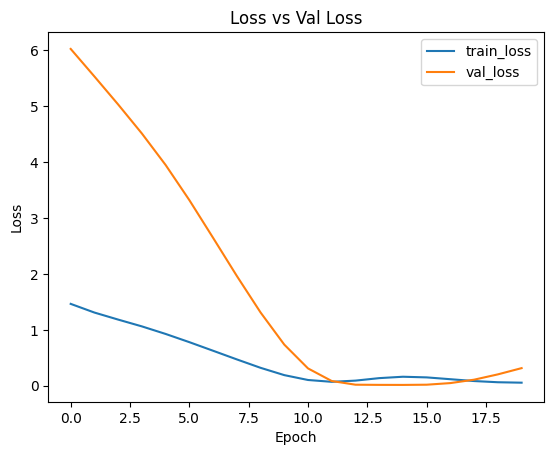

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')

plt.title('Loss vs Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [13]:
# 예측 
X_new = np.array([
    [0.2],
    [0.5],
    [0.8]
])

pred = best_model.predict(X_new)

print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
[[1.0398196]
 [1.7286168]
 [2.4199288]]


In [14]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import KFold

# =========================
# 1. 데이터
# =========================
np.random.seed(42)

X = np.linspace(0, 1, 100)
y = 3 * X + np.random.normal(0, 0.1, 100)

X = X.reshape(-1, 1)

# =========================
# 2. K-Fold 설정
# =========================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold = 1
scores = []

# =========================
# 3. K-Fold 반복
# =========================
for train_idx, val_idx in kf.split(X):

    print(f"\n🔥 Fold {fold}")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # =========================
    # 4. 모델 (매 fold마다 새로 생성)
    # =========================
    model = Sequential([
        Dense(64, activation='relu', input_shape=(1,)),
        Dense(64, activation='relu'),
        Dense(1)
    ])

    model.compile(
        optimizer='adam',
        loss='mse'
    )

    # =========================
    # 5. EarlyStopping
    # =========================
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    # =========================
    # 6. ModelCheckpoint (fold마다 파일 분리)
    # =========================
    checkpoint = ModelCheckpoint(
        f"best_model_fold_{fold}.keras",
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=0
    )

    # =========================
    # 7. 학습
    # =========================
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=200,
        callbacks=[early_stop, checkpoint],
        verbose=0
    )

    # =========================
    # 8. 평가
    # =========================
    loss = model.evaluate(X_val, y_val, verbose=0)
    scores.append(loss)

    print(f"Fold {fold} Loss: {loss}")

    fold += 1

# =========================
# 9. 최종 결과
# =========================
print("\n🔥 평균 Loss:", np.mean(scores))


🔥 Fold 1
Fold 1 Loss: 0.00607464462518692

🔥 Fold 2
Fold 2 Loss: 0.00489505659788847

🔥 Fold 3
Fold 3 Loss: 0.007855492644011974

🔥 Fold 4
Fold 4 Loss: 0.005216512829065323

🔥 Fold 5
Fold 5 Loss: 0.013253040611743927

🔥 평균 Loss: 0.007458949461579323
